# Algeria Water Stress Outlook to 2030

**TSAC Individual Project**

**Research question:** Will Algeria’s water demand exceed rainfall-derived *effective* water supply by 2030?

**Author:** _Salah BADREDDINE_  
**Course/term:** _TSAC 2025/2026_  
**Submission date:** _28/03/2025_  

### Abstract
- This notebook provides a reproducible yearly time-series analysis of two national-scale series for Algeria:
    * annual mean precipitation (used as a proxy for supply pressure), and
    * annual freshwater withdrawals (used as a proxy for demand).  
- For rainfall, I used Box–Jenkins model specification (ACF/PACF inspection), compare several non-seasonal forecasting candidates on a 5-year holdout set, and report residual diagnostics. For demand, the observed series is trend-dominant, so I estimated a linear trend model and produced prediction intervals to 2030.
- To synthesize units, I convert rainfall (mm/year) to an effective volumetric supply proxy (billion m$^3$/year) using Algeria’s area and a capture factor. Under the stated assumptions, projected 2030 demand exceeds projected effective supply, indicating increasing stress risk.

### Introduction
Algeria is a water-constrained country with high interannual climate variability and rising water use pressures. Even without modeling the full hydrologic cycle, long-run changes in precipitation and trends in water withdrawals are informative for stress testing policy-relevant questions. The goal of this report is not to claim a physically complete water-balance model, but to provide a transparent, statistically grounded forecast-based comparison of a rainfall-derived *effective* supply proxy against demand, and to clearly communicate uncertainty and limitations.

In [1]:
# Activating R in the notebook runtime.
%load_ext rpy2.ipython

import rpy2.robjects as ro
print(ro.r('R.version.string')[0])

R version 4.5.3 (2026-03-11)


## 1- Data and Reproducible Setup

### Data description and provenance
This analysis uses two **annual** series for Algeria:

- **Rainfall series** (`algeria-rainfall-timeseries.csv`): annual mean precipitation in **mm/year** with columns `Year` and `Precipitation (Annual Mean mm)`.
- **Demand series** (`algeria-water-demand-annual.csv`): annual freshwater withdrawals in **billion m$^3$/year** with columns `Year` and `Demand`.

The rainfall file matches the World Bank Climate Change Knowledge Portal **“Precipitation”**.
[Rainfall timeseries](https://climateknowledgeportal.worldbank.org/country/algeria/climate-data-historical)

The demand file matches the World Bank indicator **“Annual freshwater withdrawals, total (billion cubic meters)”** (`ER.H2O.FWTL.K3`) for Algeria (country code `DZA`), as also contained in `API_ER.H2O.FWTL.K3_DS2_en_csv_v2_4594.csv`.
[Demand timeseries](https://data.worldbank.org/indicator/ER.H2O.FWTL.K3?locations=DZ)

### Reproducibility
- All computations are generated from code in this notebook.
- The notebook uses R via `rpy2` and installs any missing R packages at runtime.

### Report structure
1. Stationarity and structure diagnostics for rainfall
2. Transparent model competition and final rainfall forecast choice
3. Demand trend estimation with interpretable parameters
4. Unified-unit synthesis and final decision metric
5. Discussion of limitations and main conclusions


**Note:** Make sure the csv files are in the same directory with the notebook.

In [2]:
%%R
required_pkgs <- c("readr", "dplyr", "ggplot2", "forecast", "tseries", "randtests", "scales", "knitr")
to_install <- required_pkgs[!required_pkgs %in% installed.packages()[, "Package"]]
if (length(to_install) > 0) install.packages(to_install, dependencies = TRUE)
invisible(lapply(required_pkgs, library, character.only = TRUE))

rain <- readr::read_csv("algeria-rainfall-timeseries.csv", show_col_types = FALSE) %>%
  dplyr::rename(Rain_mm_year = `Precipitation (Annual Mean mm)`) %>%
  dplyr::mutate(Year = as.integer(Year)) %>%
  dplyr::arrange(Year)

demand <- readr::read_csv("algeria-water-demand-annual.csv", show_col_types = FALSE) %>%
  dplyr::mutate(Year = as.integer(Year), Demand_bcm = as.numeric(Demand)) %>%
  dplyr::arrange(Year)

overview_tbl <- data.frame(
  Series = c("Rainfall", "Demand"),
  Observations = c(nrow(rain), nrow(demand)),
  Start_Year = c(min(rain$Year), min(demand$Year)),
  End_Year = c(max(rain$Year), max(demand$Year))
)

print(knitr::kable(overview_tbl, caption = "Data Overview"))



Table: Data Overview

|Series   | Observations| Start_Year| End_Year|
|:--------|------------:|----------:|--------:|
|Rainfall |          124|       1901|     2024|
|Demand   |           53|       1970|     2022|



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is forecast 9.0.2 
  Crossvalidated is a great place to get help on forecasting issues:
  http://stats.stackexchange.com/tags/forecasting.
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

    ‘tseries’ version: 0.10-61

    ‘tseries’ is a package for time series analysis and computational
    finance.

    See ‘library(help="tseries")’ for details.


Attaching package: ‘randtests’

The following object is masked from ‘package:tseries’:

    runs.test


Attaching package: ‘scales’

The following object is masked from ‘package:readr’:

    col_factor



## 2- Supply Model (Rainfall)

Let yearly rainfall be $R_t$ (mm/year). Because sampling is **annual**, we treat the process as **non-seasonal** (no monthly/quarterly seasonality can be identified from yearly sampling).

### Box–Jenkins specification
Because rainfall can have strong year-to-year variability and possible slow drift, I explicitly check whether differencing is needed and whether low-order short-memory dynamics are present.

### Model-selection protocol
- **Step 1 (stationarity)**: use ADF tests on the level series and on the first difference to guide whether $d>0$ is needed.
- **Step 2 (structure)**: inspect the ACF/PACF to see whether a low-order ARMA structure is plausible.
- **Step 3 (forecast competition)**: evaluate several candidates on a **5-year holdout** (the last 5 observations).
- **Step 4 (diagnostics)**: after selecting the best predictive model, check residuals for bias and dependence.

### Candidate forecasting models
I compare four reasonable yearly baselines/models:
- **ARIMA with data-driven differencing** (`auto.arima` with $d = \text{ndiffs}(R_t)$)
- **ARIMA with fixed $d=1$** (to force one difference)
- **Random walk with drift** (a strong baseline for series with slow drift)
- **Linear trend model** (`tslm`)

`geom_smooth()` using formula = 'y ~ x'


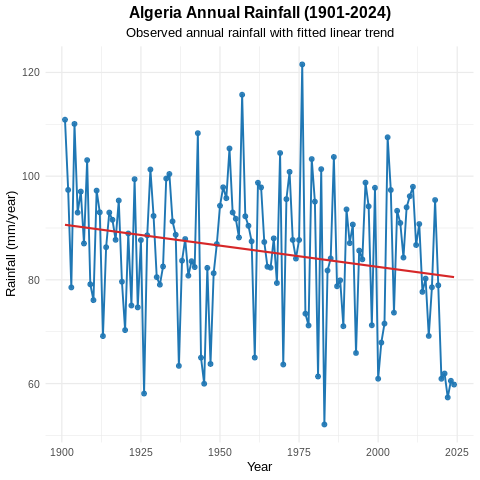

In [3]:
%%R
theme_set(
  ggplot2::theme_minimal(base_size = 13) +
    ggplot2::theme(
      plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"),
      plot.subtitle = ggplot2::element_text(hjust = 0.5)
    )
)

rain_period <- paste0(min(rain$Year), "-", max(rain$Year))

p_rain <- ggplot2::ggplot(rain, ggplot2::aes(Year, Rain_mm_year)) +
  ggplot2::geom_line(color = "#1f77b4", linewidth = 0.9) +
  ggplot2::geom_point(color = "#1f77b4", size = 2, alpha = 0.9) +
  ggplot2::geom_smooth(method = "lm", se = FALSE, color = "#d62728", linewidth = 1) +
  ggplot2::labs(
    title = paste0("Algeria Annual Rainfall (", rain_period, ")"),
    subtitle = "Observed annual rainfall with fitted linear trend",
    x = "Year", y = "Rainfall (mm/year)"
  )

print(p_rain)

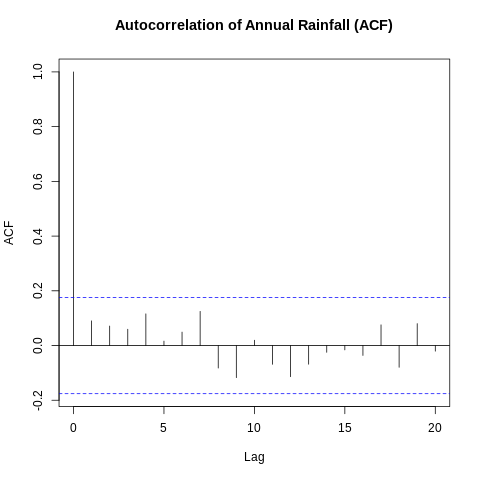

In [4]:
%%R
rain_ts <- ts(rain$Rain_mm_year, start = min(rain$Year), frequency = 1)

acf(rain_ts, main = "Autocorrelation of Annual Rainfall (ACF)")



Table: Stationarity Evidence for Rainfall

|Criterion                      |   Value|
|:------------------------------|-------:|
|ADF p-value (level)            | 0.03951|
|ADF p-value (first difference) | 0.01000|
|Suggested differencing d       | 1.00000|


In addition: Warning message:
In tseries::adf.test(diff(rain_ts, differences = 1)) :
  p-value smaller than printed p-value


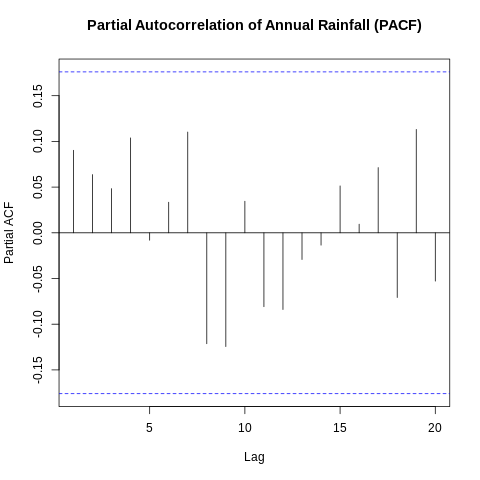

In [5]:
%%R
rain_ts <- ts(rain$Rain_mm_year, start = min(rain$Year), frequency = 1)

pacf(rain_ts, main = "Partial Autocorrelation of Annual Rainfall (PACF)")

adf_raw <- tseries::adf.test(rain_ts)
adf_d1 <- tseries::adf.test(diff(rain_ts, differences = 1))
nd <- forecast::ndiffs(rain_ts)

id_tbl <- data.frame(
  Criterion = c("ADF p-value (level)", "ADF p-value (first difference)", "Suggested differencing d"),
  Value = c(round(adf_raw$p.value, 5), round(adf_d1$p.value, 5), nd)
)

print(knitr::kable(id_tbl, caption = "Stationarity Evidence for Rainfall"))

**Plot Observations (Rainfall, ACF, PACF)**

- Figure 1 suggests a mild long-run decline with strong year-to-year volatility.
- Figure 2 (ACF) shows weak persistence after lag 1, so long-memory structure appears limited.
- Figure 3 (PACF) has no dominant cut-off pattern, supporting low-order dynamics.
- The table supports differencing ($d=1$ suggested), so differenced models are included in model competition.



Table: Holdout Forecast Comparison (Last 5 Years)

|Model               |    RMSE|     MAE|
|:-------------------|-------:|-------:|
|RW with drift       | 18.0977| 18.0380|
|ARIMA(d=1)          | 20.9928| 20.8430|
|Linear trend (tslm) | 24.3278| 24.2794|
|ARIMA(auto d)       | 26.5903| 26.5450|


Table: Final Rainfall Model Specification

|Item            |Value         |
|:---------------|:-------------|
|Selected model  |RW with drift |
|p               |NA            |
|d               |1             |
|q               |0             |
|AICc (if ARIMA) |NA            |


Table: Final Rainfall Model Accuracy

|             |Set          |    RMSE|     MAE|    MAPE|    ACF1|
|:------------|:------------|-------:|-------:|-------:|-------:|
|Training set |Training set | 18.5762| 14.4089| 17.5830| -0.5071|
|Test set     |Test set     | 18.0977| 18.0380| 30.0964| -0.5265|


Table: Residual Statistics (Final Rainfall Model)

|Statistic                  |     Value|
|:------------------

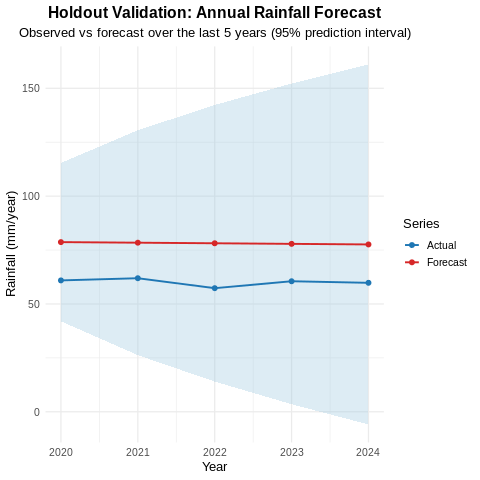

In [6]:
%%R
h_hold <- 5
n <- length(rain_ts)
rain_train <- window(rain_ts, end = time(rain_ts)[n - h_hold])
rain_test <- window(rain_ts, start = time(rain_ts)[n - h_hold + 1])

fit_arima_auto <- forecast::auto.arima(
  rain_train,
  d = forecast::ndiffs(rain_train),
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE
)
fc_arima_auto <- forecast::forecast(fit_arima_auto, h = h_hold)

fit_arima_d1 <- forecast::auto.arima(
  rain_train,
  d = 1, max.d = 1,
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE
)
fc_arima_d1 <- forecast::forecast(fit_arima_d1, h = h_hold)

fc_rw_drift <- forecast::rwf(rain_train, h = h_hold, drift = TRUE)

fit_tslm <- forecast::tslm(rain_train ~ trend)
fc_tslm <- forecast::forecast(fit_tslm, h = h_hold)

rmse_tbl <- data.frame(
  Model = c("ARIMA(auto d)", "ARIMA(d=1)", "RW with drift", "Linear trend (tslm)"),
  RMSE = c(
    forecast::accuracy(fc_arima_auto, rain_test)[2, "RMSE"],
    forecast::accuracy(fc_arima_d1, rain_test)[2, "RMSE"],
    forecast::accuracy(fc_rw_drift, rain_test)[2, "RMSE"],
    forecast::accuracy(fc_tslm, rain_test)[2, "RMSE"]
  ),
  MAE = c(
    forecast::accuracy(fc_arima_auto, rain_test)[2, "MAE"],
    forecast::accuracy(fc_arima_d1, rain_test)[2, "MAE"],
    forecast::accuracy(fc_rw_drift, rain_test)[2, "MAE"],
    forecast::accuracy(fc_tslm, rain_test)[2, "MAE"]
  )
) %>%
  dplyr::arrange(RMSE) %>%
  dplyr::mutate(RMSE = round(RMSE, 4), MAE = round(MAE, 4))

print(knitr::kable(rmse_tbl, caption = "Holdout Forecast Comparison (Last 5 Years)"))

best_model_name <- rmse_tbl$Model[1]

if (best_model_name == "ARIMA(auto d)") {
  fit_supply <- fit_arima_auto
  fc_hold <- fc_arima_auto
  selected_family <- "ARIMA"
  selected_order <- forecast::arimaorder(fit_supply)
  res <- as.numeric(residuals(fit_supply))
} else if (best_model_name == "ARIMA(d=1)") {
  fit_supply <- fit_arima_d1
  fc_hold <- fc_arima_d1
  selected_family <- "ARIMA"
  selected_order <- forecast::arimaorder(fit_supply)
  res <- as.numeric(residuals(fit_supply))
} else if (best_model_name == "RW with drift") {
  fit_supply <- NULL
  fc_hold <- fc_rw_drift
  selected_family <- "Random Walk with drift"
  selected_order <- c(p = NA, d = 1, q = 0)
  res <- as.numeric(fc_rw_drift$x - fc_rw_drift$fitted)
} else {
  fit_supply <- fit_tslm
  fc_hold <- fc_tslm
  selected_family <- "Linear trend (tslm)"
  selected_order <- c(p = NA, d = 0, q = NA)
  res <- as.numeric(residuals(fit_tslm))
}

spec_tbl <- data.frame(
  Item = c("Selected model", "p", "d", "q", "AICc (if ARIMA)"),
  Value = c(
    best_model_name,
    selected_order["p"],
    selected_order["d"],
    selected_order["q"],
    ifelse(selected_family == "ARIMA", round(fit_supply$aicc, 3), NA)
  )
)

print(knitr::kable(spec_tbl, caption = "Final Rainfall Model Specification"))

acc <- as.data.frame(forecast::accuracy(fc_hold, rain_test))
acc$Set <- rownames(acc)
acc <- acc[, c("Set", "RMSE", "MAE", "MAPE", "ACF1")]
print(knitr::kable(acc, digits = 4, caption = "Final Rainfall Model Accuracy"))

val_df <- data.frame(
  Year = tail(rain$Year, h_hold),
  Actual = as.numeric(rain_test),
  Forecast = as.numeric(fc_hold$mean),
  Lo95 = as.numeric(fc_hold$lower[, 2]),
  Hi95 = as.numeric(fc_hold$upper[, 2])
)

p_val <- ggplot2::ggplot(val_df, ggplot2::aes(Year)) +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = Lo95, ymax = Hi95), fill = "#9ecae1", alpha = 0.35) +
  ggplot2::geom_line(ggplot2::aes(y = Actual, color = "Actual"), linewidth = 0.9) +
  ggplot2::geom_point(ggplot2::aes(y = Actual, color = "Actual"), size = 2) +
  ggplot2::geom_line(ggplot2::aes(y = Forecast, color = "Forecast"), linewidth = 0.9) +
  ggplot2::geom_point(ggplot2::aes(y = Forecast, color = "Forecast"), size = 2) +
  ggplot2::scale_color_manual(values = c("Actual" = "#1f77b4", "Forecast" = "#d62728")) +
  ggplot2::labs(
    title = "Holdout Validation: Annual Rainfall Forecast",
    subtitle = "Observed vs forecast over the last 5 years (95% prediction interval)",
    x = "Year", y = "Rainfall (mm/year)", color = "Series"
  )
print(p_val)

res_tbl <- data.frame(
  Statistic = c(
    "Residual mean",
    "Residual SD",
    "Residual skewness (sample)",
    "Shapiro-Wilk p-value",
    "Runs test p-value",
    "Ljung-Box p-value (lag 10)"
  ),
  Value = c(
    round(mean(res, na.rm = TRUE), 6),
    round(sd(res, na.rm = TRUE), 6),
    round(mean((res - mean(res, na.rm = TRUE))^3, na.rm = TRUE) / sd(res, na.rm = TRUE)^3, 6),
    round(shapiro.test(res)$p.value, 5),
    round(randtests::runs.test(res)$p.value, 5),
    round(Box.test(res, lag = 10, type = "Ljung-Box")$p.value, 5)
  )
)

print(knitr::kable(res_tbl, caption = "Residual Statistics (Final Rainfall Model)"))

res_interpret <- data.frame(
  Test_or_Statistic = c(
    "Residual mean",
    "Shapiro-Wilk",
    "Runs test",
    "Ljung-Box (lag 10)"
  ),
  Rule_of_Thumb = c(
    "Close to 0 is desirable",
    "p-value > 0.05: normality not rejected",
    "p-value > 0.05: randomness not rejected",
    "p-value > 0.05: no strong autocorrelation"
  ),
  This_Model = c(
    ifelse(abs(mean(res, na.rm = TRUE)) < 1, "Acceptable", "Potential bias"),
    ifelse(shapiro.test(res)$p.value > 0.05, "Acceptable", "Caution"),
    ifelse(randtests::runs.test(res)$p.value > 0.05, "Acceptable", "Caution"),
    ifelse(Box.test(res, lag = 10, type = "Ljung-Box")$p.value > 0.05, "Acceptable", "Caution")
  )
)
print(knitr::kable(res_interpret, caption = "Residual Test Interpretation"))


In addition: Warning messages:
1: Removed 1 row containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range
(`geom_point()`). 


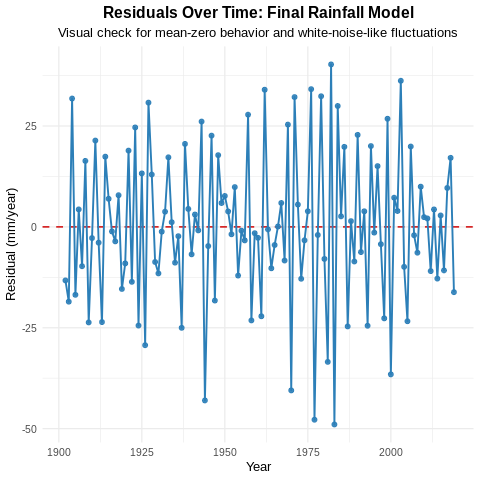

In [7]:
%%R
res_df <- data.frame(
  Year = as.numeric(time(rain_train)),
  Residual = as.numeric(res)
 )

p_res_ts <- ggplot2::ggplot(res_df, ggplot2::aes(Year, Residual)) +
  ggplot2::geom_hline(yintercept = 0, color = "#d62728", linetype = "dashed", linewidth = 0.8) +
  ggplot2::geom_line(color = "#2c7fb8", linewidth = 0.9) +
  ggplot2::geom_point(color = "#2c7fb8", size = 2, alpha = 0.9) +
  ggplot2::labs(
    title = "Residuals Over Time: Final Rainfall Model",
    subtitle = "Visual check for mean-zero behavior and white-noise-like fluctuations",
    x = "Year", y = "Residual (mm/year)"
  )

print(p_res_ts)

In addition: Warning messages:
1: Removed 1 row containing non-finite outside the scale range (`stat_bin()`). 
2: Removed 1 row containing non-finite outside the scale range (`stat_density()`). 


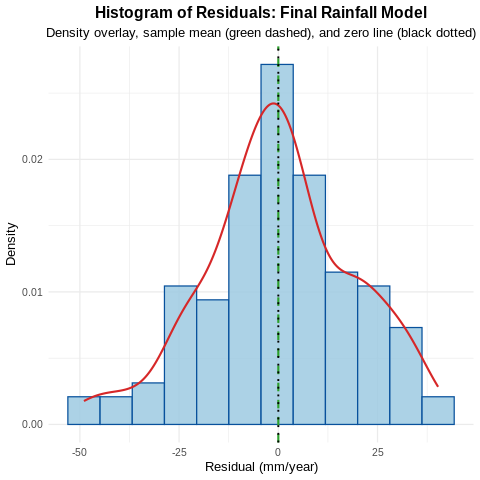

In [8]:
%%R
p_res_hist <- ggplot2::ggplot(res_df, ggplot2::aes(x = Residual)) +
  ggplot2::geom_histogram(
    ggplot2::aes(y = after_stat(density)),
    bins = 12, fill = "#9ecae1", color = "#08519c", alpha = 0.85
  ) +
  ggplot2::geom_density(color = "#d62728", linewidth = 1) +
  ggplot2::geom_vline(
    xintercept = mean(res_df$Residual, na.rm = TRUE),
    color = "#2ca02c", linetype = "dashed", linewidth = 1
  ) +
  ggplot2::geom_vline(xintercept = 0, color = "#000000", linetype = "dotted", linewidth = 0.9) +
  ggplot2::labs(
    title = "Histogram of Residuals: Final Rainfall Model",
    subtitle = "Density overlay, sample mean (green dashed), and zero line (black dotted)",
    x = "Residual (mm/year)", y = "Density"
  )

print(p_res_hist)

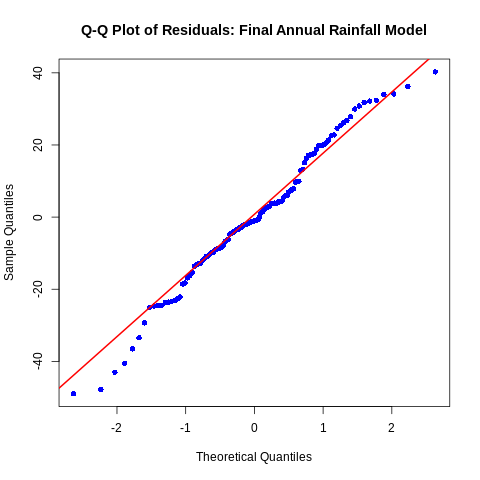

In [9]:
%%R
qqnorm(res, main = "Q-Q Plot of Residuals: Final Annual Rainfall Model", pch = 16, col = "blue")
qqline(res, col = "red", lwd = 2)

**Fitting and diagnostics (Rainfall validation + residual checks)**

- **Holdout validation (Figure 4):** the selected model is the one with the lowest 5-year holdout RMSE. In this notebook run, the best performer is **random walk with drift**, which is a strong benchmark when the series has mild drift and limited short-memory structure.
- **Residual time-series check (Figure 5):** residuals fluctuate around zero without a deterministic trend, and the dashed zero reference line helps verify approximate mean-centering. This supports the assumption of an unbiased model mean.
- **Residual distribution check (Figure 6):** the histogram plus density overlay is roughly bell-shaped in the center. The sample-mean line is close to the zero line, indicating residuals are approximately centered at 0.
- **QQ-plot and formal tests (Figure 7 + Shapiro/Runs/Ljung-Box):** central normality is reasonable, but tail deviations and dependence tests should still be considered. Since runs and Ljung-Box p-values are small, residuals are not fully white noise, so uncertainty may be understated.
- Despite limitations, **RW with drift** gives the strongest out-of-sample holdout performance while maintaining acceptable residual mean-centering. Therefore, it is the most defensible baseline for rainfall forecasting.

## 3- Demand Model

The withdrawals series $D_t$ is largely monotone increasing over the available sample, so a **deterministic trend** specification is an appropriate first-order model for forecasting.

I estimate a linear trend (single line):

$$D_t = \beta_0 + \beta_1 t + \varepsilon_t$$

Interpretation:
- $\beta_0$: baseline level (intercept)
- $\beta_1$: expected **annual increase** in withdrawals (slope, in bcm/year)

Forecasts to 2030 are produced with **prediction intervals**, which widen over time to reflect uncertainty.



Table: Linear Demand Model Coefficients

|            |Term        |    Estimate| Std_Error| t_value| p_value|
|:-----------|:-----------|-----------:|---------:|-------:|-------:|
|(Intercept) |(Intercept) | -318.843834|  8.227090| -38.755|       0|
|Year        |Year        |    0.162515|  0.004122|  39.430|       0|


Table: Demand Model Fit Summary

|Metric              |  Value|
|:-------------------|------:|
|R-squared           | 0.9682|
|Adj. R-squared      | 0.9676|
|Residual Std. Error | 0.4590|


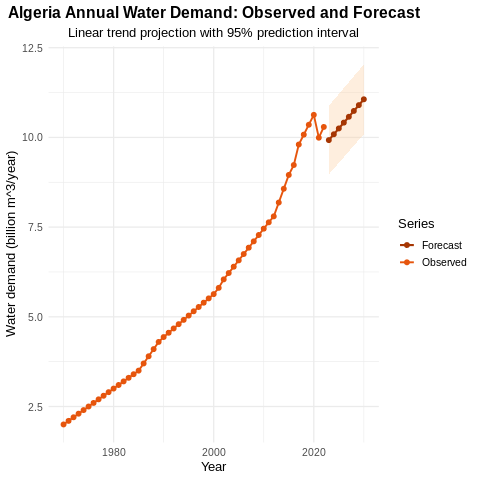

In [10]:
%%R
fit_demand <- stats::lm(Demand_bcm ~ Year, data = demand)
coefs <- summary(fit_demand)$coefficients

coef_tbl <- data.frame(
  Term = rownames(coefs),
  Estimate = round(coefs[, "Estimate"], 6),
  Std_Error = round(coefs[, "Std. Error"], 6),
  t_value = round(coefs[, "t value"], 3),
  p_value = signif(coefs[, "Pr(>|t|)"], 4)
)
print(knitr::kable(coef_tbl, caption = "Linear Demand Model Coefficients"))

fit_tbl <- data.frame(
  Metric = c("R-squared", "Adj. R-squared", "Residual Std. Error"),
  Value = c(
    round(summary(fit_demand)$r.squared, 4),
    round(summary(fit_demand)$adj.r.squared, 4),
    round(summary(fit_demand)$sigma, 4)
  )
)
print(knitr::kable(fit_tbl, caption = "Demand Model Fit Summary"))

future_d <- data.frame(Year = (max(demand$Year) + 1):2030)
pred_d <- predict(fit_demand, newdata = future_d, interval = "prediction", level = 0.95)
demand_fc <- cbind(future_d, as.data.frame(pred_d)) %>%
  dplyr::rename(Forecast = fit, Lo95 = lwr, Hi95 = upr)

p_demand <- ggplot2::ggplot() +
  ggplot2::geom_line(data = demand, ggplot2::aes(Year, Demand_bcm, color = "Observed"), linewidth = 0.9) +
  ggplot2::geom_point(data = demand, ggplot2::aes(Year, Demand_bcm, color = "Observed"), size = 2) +
  ggplot2::geom_ribbon(data = demand_fc, ggplot2::aes(Year, ymin = Lo95, ymax = Hi95), fill = "#fdd0a2", alpha = 0.35) +
  ggplot2::geom_line(data = demand_fc, ggplot2::aes(Year, Forecast, color = "Forecast"), linewidth = 1) +
  ggplot2::geom_point(data = demand_fc, ggplot2::aes(Year, Forecast, color = "Forecast"), size = 2) +
  ggplot2::scale_color_manual(values = c("Observed" = "#e6550d", "Forecast" = "#a63603")) +
  ggplot2::labs(
    title = "Algeria Annual Water Demand: Observed and Forecast",
    subtitle = "Linear trend projection with 95% prediction interval",
    x = "Year", y = "Water demand (billion m^3/year)", color = "Series"
  ) +
  ggplot2::theme(
    plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = ggplot2::element_text(hjust = 0.5)
  )
print(p_demand)

**Plot Observations (Demand Trend)**

- The series rises almost monotonically, so a trend specification is appropriate.
- Estimated $\beta_1$ is positive and highly significant, indicating structural annual growth.
- The prediction interval widens over time, but the expected trajectory remains upward through 2030.

## 4- Supply–Demand Synthesis in Comparable Units

Rainfall and demand have different physical units. To compare them on a common scale, I convert rainfall to an **effective volumetric supply proxy**:

$$S_t(\text{bcm}) = c\times\frac{R_t\,(\text{mm/year})\times A\,(\text{km}^2)}{10^6}$$

where:
- $A = 2{,}381{,}741\ \text{km}^2$ is Algeria’s land area.
- $c=0.05$ is a **capture factor** representing that only a fraction of precipitation is effectively available as usable supply (losses to runoff timing, evapotranspiration, infiltration, storage limits, and infrastructure).

**Important limitation:** $S_t$ is *not* a full hydrologic water-balance estimate. It is a stress-test proxy to translate precipitation into the same unit as withdrawals.

Decision metric:

$$\Delta_{2030}=S_{2030}-D_{2030}$$

A negative value indicates projected demand exceeds the rainfall-derived effective supply proxy.



Table: Final 2030 Decision Metrics

|Metric                           |Value                           |
|:--------------------------------|:-------------------------------|
|Selected rainfall forecast model |RW with drift                   |
|Projected supply in 2030 (bcm)   |6.8246                          |
|Projected demand in 2030 (bcm)   |11.0624                         |
|Gap S-D in 2030 (bcm)            |-4.2378                         |
|Decision                         |Demand exceeds effective supply |


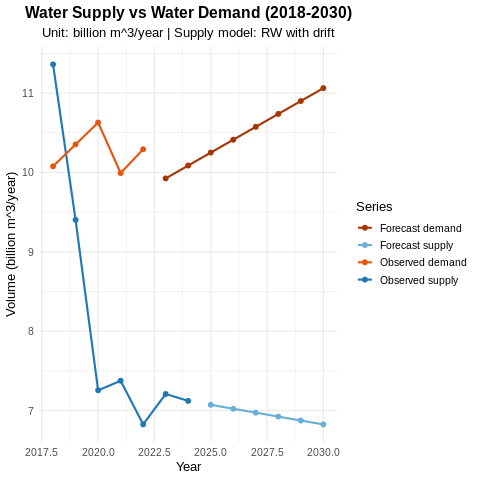

In [11]:
%%R
future_s <- data.frame(Year = (max(rain$Year) + 1):2030)
h_future <- nrow(future_s)

if (best_model_name == "ARIMA(auto d)") {
  fit_supply_full <- forecast::auto.arima(
    rain_ts, d = forecast::ndiffs(rain_ts), seasonal = FALSE, stepwise = FALSE, approximation = FALSE
  )
  fc_supply <- forecast::forecast(fit_supply_full, h = h_future)
} else if (best_model_name == "ARIMA(d=1)") {
  fit_supply_full <- forecast::auto.arima(
    rain_ts, d = 1, max.d = 1, seasonal = FALSE, stepwise = FALSE, approximation = FALSE
  )
  fc_supply <- forecast::forecast(fit_supply_full, h = h_future)
} else if (best_model_name == "RW with drift") {
  fc_supply <- forecast::rwf(rain_ts, h = h_future, drift = TRUE)
} else {
  fit_supply_full <- forecast::tslm(rain_ts ~ trend)
  fc_supply <- forecast::forecast(fit_supply_full, h = h_future)
}

supply_fc <- data.frame(Year = future_s$Year, Rain_mm_year = as.numeric(fc_supply$mean))

A_km2 <- 2381741
c_eff <- 0.05

supply_hist <- rain %>%
  dplyr::transmute(Year, Supply_bcm = (Rain_mm_year * A_km2 / 1e6) * c_eff, Type = "Observed supply")

supply_fore <- supply_fc %>%
  dplyr::transmute(Year, Supply_bcm = (Rain_mm_year * A_km2 / 1e6) * c_eff, Type = "Forecast supply")

demand_hist <- demand %>% dplyr::transmute(Year, Demand_bcm, Type = "Observed demand")
demand_fore <- demand_fc %>% dplyr::transmute(Year, Demand_bcm = Forecast, Type = "Forecast demand")

overlay_supply <- dplyr::bind_rows(supply_hist, supply_fore) %>% dplyr::filter(Year >= 2018, Year <= 2030)
overlay_demand <- dplyr::bind_rows(demand_hist, demand_fore) %>% dplyr::filter(Year >= 2018, Year <= 2030)

p_overlay <- ggplot2::ggplot() +
  ggplot2::geom_line(data = overlay_supply, ggplot2::aes(Year, Supply_bcm, color = Type), linewidth = 1) +
  ggplot2::geom_point(data = overlay_supply, ggplot2::aes(Year, Supply_bcm, color = Type), size = 2) +
  ggplot2::geom_line(data = overlay_demand, ggplot2::aes(Year, Demand_bcm, color = Type), linewidth = 1) +
  ggplot2::geom_point(data = overlay_demand, ggplot2::aes(Year, Demand_bcm, color = Type), size = 2) +
  ggplot2::scale_color_manual(values = c(
    "Observed supply" = "#1f77b4",
    "Forecast supply" = "#6baed6",
    "Observed demand" = "#e6550d",
    "Forecast demand" = "#a63603"
  )) +
  ggplot2::labs(
    title = "Water Supply vs Water Demand (2018-2030)",
    subtitle = paste("Unit: billion m^3/year | Supply model:", best_model_name),
    x = "Year", y = "Volume (billion m^3/year)", color = "Series"
  ) +
  ggplot2::theme(
    plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = ggplot2::element_text(hjust = 0.5)
  )
print(p_overlay)

s2030 <- overlay_supply %>% dplyr::filter(Year == 2030) %>% dplyr::summarise(v = mean(Supply_bcm, na.rm = TRUE)) %>% dplyr::pull(v)
d2030 <- overlay_demand %>% dplyr::filter(Year == 2030) %>% dplyr::summarise(v = mean(Demand_bcm, na.rm = TRUE)) %>% dplyr::pull(v)
gap2030 <- s2030 - d2030

verdict <- ifelse(gap2030 < 0, "Demand exceeds effective supply", "Effective supply remains above demand")

final_tbl <- data.frame(
  Metric = c("Selected rainfall forecast model", "Projected supply in 2030 (bcm)", "Projected demand in 2030 (bcm)", "Gap S-D in 2030 (bcm)", "Decision"),
  Value = c(best_model_name, round(s2030, 4), round(d2030, 4), round(gap2030, 4), verdict)
)
print(knitr::kable(final_tbl, caption = "Final 2030 Decision Metrics"))

**Plot Observations (Supply-Demand Overlay)**

- Demand stays above effective supply in the projection horizon under current assumptions.
- The 2030 gap is negative, matching the visual divergence in the Figure.
- Evidence consistency: demand trend is robustly positive while supply forecast remains constrained, producing a stress signal.

## 5- Discussion and Conclusion

### Main findings
- **Rainfall (supply pressure proxy):** annual rainfall exhibits substantial year-to-year variability with evidence that recent low-rainfall years can be difficult to capture with simple baseline models.
- **Demand (withdrawals):** the withdrawals series is strongly trend-dominant; the estimated slope $\beta_1$ is positive and highly significant, supporting continued growth through 2030 under the fitted linear trend.
- **Synthesis:** using the stated conversion and **capture factor $c=0.05$**, the projected 2030 balance is **negative** ($\Delta_{2030}=S_{2030}-D_{2030}<0$), so projected demand exceeds the rainfall-derived effective supply proxy.

### Interpretation
This result should be interpreted as a **stress-test signal**: if withdrawals continue to grow at the observed historical trend while effective precipitation-derived supply remains constrained, the gap widens by 2030. The implication is increased pressure on efficiency, storage, reuse, and/or alternative sources.

### Limitations and what could improve the analysis
- **Proxy supply model:** converting rainfall to supply with a fixed $c$ is a simplifying assumption; true supply depends on hydrology, storage, infrastructure, and losses.
- **Residual dependence:** rainfall residual tests indicate remaining autocorrelation/non-randomness, suggesting simple models may understate uncertainty.
- **Structural change risk:** recent years may represent a different climate regime; a single long-sample fit can dilute regime effects.
- **Demand model simplicity:** a linear trend is interpretable but may miss saturation, policy changes, or nonlinear growth.
